<a href="https://colab.research.google.com/github/kiu2225/Deep_Learning/blob/main/01_keras_practicals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Keras Practicals — Three Projects, One Workflow

Welcome! In this notebook we solve **three classic deep-learning tasks** with Keras 3 (TensorFlow backend):

| Practical | Task | Dataset | Output layer | Loss |
|---|---|---|---|---|
| 1 | Binary classification | Breast Cancer (30 features) | 1 sigmoid unit | `binary_crossentropy` |
| 2 | Multi-class classification | Iris (3 flower species) | 3 softmax units | `sparse_categorical_crossentropy` |
| 3 | Regression | California Housing (house prices) | 1 linear unit | `mse` |

The architecture and preprocessing are **identical** in all three — only the *last layer* and the *loss* change. That is the main lesson: **the deep learning workflow stays the same; the output/loss pair adapts to the task.**

## How to run this notebook in Google Colab

1. Go to <https://colab.research.google.com> and upload this file (or open it from GitHub/Drive).
2. Select **Runtime → Change runtime type → T4 GPU** (any GPU works; the models are small enough that even CPU would run them).
3. Select **Runtime → Run all**. The first cell installs the libraries; the rest trains three small models in a couple of minutes.

No other setup is needed — every cell is self-contained.

## The deep learning workflow

Every practical in this notebook (and every PyTorch practical you will see next) walks through the **same seven stages**. Read this diagram left to right — by the end of the notebook you will have done each stage three times.

```mermaid
flowchart LR
    A[1. Raw data<br/>sklearn dataset] --> B[2. Preprocess<br/>train_test_split + StandardScaler]
    B --> C[3. Build model<br/>keras.Sequential]
    C --> D[4. Compile<br/>model.compile<br/>optimizer + loss + metrics]
    D --> E[5. Train<br/>model.fit<br/>returns History]
    E --> F[6. Evaluate<br/>model.evaluate<br/>on held-out test set]
    F --> G[7. Predict + visualize<br/>model.predict + matplotlib]
```

Notice that the middle stages are just **three Keras calls**: `Sequential`, `compile`, `fit`. Keras does the heavy lifting; your job is to choose the data, the architecture, and the output/loss pair that matches the task.

## Keras ↔ PyTorch vocabulary

You will see these same tasks again in the PyTorch notebook. Use this table to translate between the two frameworks — the *concepts* are identical, only the names change.

| Concept | Keras (this notebook) | PyTorch (next notebook) |
|---|---|---|
| Define the network | `keras.Sequential([...])` | `class Net(nn.Module)` with `nn.Linear` layers |
| Choose how to learn | `model.compile(optimizer, loss, metrics)` | construct a loss (`nn.*Loss`) and optimizer (`torch.optim.Adam`) separately |
| Train | `model.fit(X, y, epochs=...)` — one call | manual loop: forward → loss → `zero_grad` → `backward` → `optimizer.step()` |
| Get predictions | `model.predict(X)` | forward pass `net(X)` in `eval()` mode |
| Measure on test data | `model.evaluate(X, y)` | loop over the test set with `torch.no_grad()` |
| Training history | `History` object returned by `fit` | lists you append to yourself in the loop |

---
## Section 0 — Setup

First we install the libraries (a fresh Colab runtime already has most of them, but pinning the install makes the notebook run *anywhere*), then we import everything and print the Keras version so we know exactly what we are using.

In [ ]:
# Install the libraries this notebook needs (quietly: -q hides pip's progress bars).
# {sys.executable} inserts the full path of the Python interpreter running THIS notebook,
# so we install into the right environment instead of whatever 'pip' happens to be on PATH.
import sys  # sys.executable = e.g. /usr/bin/python3 inside Colab

#!{sys.executable} -m pip install -q tensorflow keras scikit-learn matplotlib

In [ ]:
import numpy as np  # numpy arrays are what sklearn datasets and Keras both use under the hood
import matplotlib.pyplot as plt  # matplotlib draws all our plots; plt.show() renders them inline

import keras  # Keras 3 — the high-level deep-learning API we use throughout
from keras import layers  # layers.Dense etc. — the building blocks of our models

# Set every random seed Keras/TensorFlow uses (weights init, shuffling, dropout).
# Without this, two identical runs can give slightly different accuracies,
# which is confusing when you are learning.
keras.utils.set_random_seed(42)

print(f"Keras version: {keras.__version__}")  # sanity check — should be Keras 3.x on Colab

Keras version: 3.13.2


In [ ]:
!nvidia-smi

Wed Sep  9 15:58:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
# Practical 1 — Binary Classification: Breast Cancer

**Task:** given 30 numeric measurements of a tumour, predict whether it is **malignant** (`0`) or **benign** (`1`). This is *binary* classification — every answer is one of two options — so the model must end in a single number between 0 and 1 (a probability).

### The task pipeline

Follow the diagram: the choices we make at the end (sigmoid output + `binary_crossentropy`) are dictated by the task being *binary*.

```mermaid
flowchart LR
    A[Dataset<br/>breast_cancer<br/>569 tumours, 30 features] --> B[Features X and labels y<br/>X: 569 x 30<br/>y: 569 values of 0/1]
    B --> C[train_test_split<br/>80% train / 20% test<br/>stratify=y keeps class balance]
    C --> D[StandardScaler<br/>fit on TRAIN only<br/>mean 0, std 1]
    D --> E[Model<br/>Dense 64 relu<br/>Dense 64 relu]
    E --> F[Output: Dense 1 sigmoid<br/>one probability in 0 to 1<br/>because there are 2 classes]
    F --> G[Loss: binary_crossentropy<br/>compares probability to 0/1 label]
```

We walk through the same 8 steps every time: **(1) load & inspect → (2) preprocess → (3) build → (4) compile → (5) train → (6) evaluate → (7) predict → (8) visualize.**

### Step 1 — Load & inspect the data

Never train on data you haven't looked at. `load_breast_cancer()` gives us a `Bunch` object (like a dictionary) with the feature matrix `.data` and the label vector `.target`. We print shapes and class counts so we know what we're dealing with.

In [ ]:
from sklearn.datasets import load_breast_cancer  # classic, clean, real medical dataset

# load_breast_cancer() returns a Bunch (dict-like) with .data (features) and .target (labels).
cancer = load_breast_cancer()
X = cancer.data    # numpy array, shape (569, 30): 569 tumours, 30 numeric measurements each
y = cancer.target  # numpy array, shape (569,): 0 = malignant, 1 = benign

print(f"Features shape: {X.shape}")            # (n_samples, n_features)
print(f"Target shape  : {y.shape}")             # (n_samples,)
print(f"Class counts  : {np.bincount(y)}")      # bincount tallies the 0s and 1s -> class balance
print(f"First 5 feature names: {list(cancer.feature_names[:5])}")  # e.g. mean radius, mean texture

Features shape: (569, 30)
Target shape  : (569,)
Class counts  : [212 357]
First 5 feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]


### Step 2 — Preprocess: split, then scale

Two rules we follow in **every** practical:

1. **Split first**: hold out 20% of the data as a test set the model never sees during training. `random_state=42` makes the split reproducible, and `stratify=y` guarantees the same malignant/benign ratio in both subsets.
2. **Scale features**: neural nets train faster when all inputs have similar magnitudes. `StandardScaler` shifts each feature to mean 0, std 1. The golden rule: **fit the scaler on the training set only**, then use the same numbers on the test set — otherwise test-set information leaks into training.

In [ ]:
from sklearn.model_selection import train_test_split  # splits arrays into train and test subsets
from sklearn.preprocessing import StandardScaler       # rescales features to mean 0 / std 1

# test_size=0.2 -> 80% train, 20% test. random_state=42 -> identical split on every run.
# stratify=y -> both subsets keep the same 0/1 ratio (matters when classes are imbalanced).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# StandardScaler learns each feature's mean and std deviation.
# CRITICAL: .fit_transform() on TRAIN only — the test set must stay 'unseen'.
scaler = StandardScaler()                  # creates the scaler object (learns nothing yet)
X_train = scaler.fit_transform(X_train)    # learns mean/std FROM train, then rescales train -> still (455, 30)
X_test = scaler.transform(X_test)          # reuses the SAME mean/std on test -> (114, 30), no re-fitting

print(f"Train: X{X_train.shape}, y{y_train.shape}")  # 455 samples for training
print(f"Test : X{X_test.shape}, y{y_test.shape}")    # 114 samples held out for the final check

Train: X(455, 30), y(455,)
Test : X(114, 30), y(114,)


### Step 3 — Build the model

In Keras you describe a network as a **stack of layers**. Data flows through them in order:

- `layers.Input(shape=(30,))` only declares the shape of one sample — it does no math. You could also put `input_shape=(30,)` on the first `Dense`.
- `layers.Dense(64, activation='relu')` is a *fully-connected* layer: every one of its 64 neurons looks at every input number. `relu` (Rectified Linear Unit) turns negative values into 0, which lets the network learn non-straight patterns.
- `layers.Dense(1, activation='sigmoid')` is the output. **Sigmoid squashes any number into the range 0–1**, which we read as "probability that the tumour is benign". One output unit because there are exactly two classes.

In [ ]:
# keras.Sequential stacks layers so data flows through them top to bottom.
model = keras.Sequential([
    layers.Input(shape=(30,)),              # declares: each sample arrives as 30 numbers
    layers.Dense(64, activation='relu'),    # hidden layer 1: 64 neurons, each connected to all 30 inputs
    #layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),    # hidden layer 2: 64 neurons — deeper = more complex patterns
    layers.Dense(1, activation='sigmoid'),  # output: 1 sigmoid unit -> probability of class 1 (benign)
])

model.summary()  # prints a layer table with output shapes and the number of trainable parameters

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,209 (24.25 KB)

 Trainable params: 6,209 (24.25 KB)

 Non-trainable params: 0 (0.00 B)

### Step 4 — Compile: choose how the model learns

`compile()` doesn't train anything — it **configures** training by picking three things:

- **optimizer** (`'adam'`): the algorithm that updates the weights. Adam adapts the step size automatically and is the best default for beginners.
- **loss** (`'binary_crossentropy'`): the single number training tries to shrink. For a sigmoid probability and a 0/1 label, cross-entropy measures "how wrong is the confidence?"
- **metrics** (`['accuracy']`): extra numbers we humans want to watch. They are *not* used to update weights — purely for us.

In [ ]:
# optimizer='adam'     : Adam optimizer — good default, needs no manual learning-rate tuning.
# loss                 : must MATCH the output layer — sigmoid output pairs with binary_crossentropy.
# metrics=['accuracy'] : an extra report number for humans; never affects training itself.
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

### Step 5 — Train with fit()

`fit()` is the one call that actually trains. Three arguments to understand:

- `epochs=50`: the full training set is shown to the model 50 times.
- `batch_size=32`: weights update after every 32 samples — small batches make updates frequent and noisy, which helps learning.
- `validation_split=0.2`: Keras quietly peels off 20% of the *training* data before each epoch and measures loss/accuracy on it. Training data it learns from; validation data it only gets *tested* on — the gap between the two curves (below) reveals overfitting.

`fit()` returns a **`History` object**: `history.history` is a dict like `{'loss': [...50 values...], 'val_loss': [...], 'accuracy': [...], 'val_accuracy': [...]}` — one value per epoch, which we plot in step 8.

In [ ]:
# model.fit TRAINS the model and returns a History object (we keep it in 'history').
history = model.fit(X_train, y_train,          # training features and labels
                    validation_split=0.2,      # 20% of train reserved as validation each epoch
                    epochs=20,                 # 50 full passes over the training data
                    batch_size=32,             # update weights every 32 samples
                    verbose=1)                 # 1 = print one progress line per epoch

# history.history: dict of lists, one number per epoch — this is where our plots come from.
print("Keys in history.history:", list(history.history.keys()))

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.7527 - loss: 0.5647 - val_accuracy: 0.9670 - val_loss: 0.3727
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.2937 - val_accuracy: 0.9670 - val_loss: 0.2140
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1785 - val_accuracy: 0.9780 - val_loss: 0.1398
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9725 - loss: 0.1254 - val_accuracy: 0.9780 - val_loss: 0.1028
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0978 - val_accuracy: 0.9780 - val_loss: 0.0820
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9835 - loss: 0.0822 - val_accuracy: 0.9780 - val_loss: 0.0692
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9863 - loss: 0.0727 - val_accuracy: 0.9780 - val_loss: 0.0609
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9890 - loss: 0.0662 - val_accuracy: 0.9890 - val_l

### Step 6 — Evaluate on the held-out test set

The test set has been invisible until now. `evaluate()` runs the model on it and returns the loss and metrics **in the same order** they were given to `compile()` — here `[loss, accuracy]`.

This is the number that matters. Validation numbers flatter the model; test numbers are honest.

In [ ]:
# model.evaluate returns [loss, accuracy] in compile() order; verbose=0 silences the progress bar.
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test loss (binary_crossentropy): {test_loss:.4f}")              # lower = more confident & correct
print(f"Test accuracy: {test_accuracy:.4f}  ->  {test_accuracy*100:.1f}% of tumours classified correctly")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9561 - loss: 0.0836
Test loss (binary_crossentropy): 0.0836
Test accuracy: 0.9561  ->  95.6% of tumours classified correctly


### Step 7 — Predict: from probabilities to answers

`predict()` gives **raw outputs** — for this model, probabilities between 0 and 1. A probability isn't an answer yet; we turn it into one by **thresholding at 0.5**: `>= 0.5` → benign (`1`), otherwise malignant (`0`). 0.5 is the default cut-off because sigmoid outputs centre around it.

In [ ]:
# model.predict returns raw sigmoid probabilities, shape (114, 1) — floats in (0, 1).
y_prob = model.predict(X_test, verbose=1)          # e.g. [[0.97], [0.03], ...] = P(benign)
y_pred = (y_prob > 0.5).astype(int)                # threshold at 0.5 -> hard 0/1 answers, same shape

# Compare the first 5 predictions with the true labels.
for i in range(25):  # loop over the first 5 test samples
    print(f"sample {i}: P(benign)={y_prob[i][0]:.3f} -> predicted {y_pred[i][0]}, true {y_test[i]}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
sample 0: P(benign)=0.000 -> predicted 0, true 0
sample 1: P(benign)=1.000 -> predicted 1, true 1
sample 2: P(benign)=0.001 -> predicted 0, true 0
sample 3: P(benign)=0.404 -> predicted 0, true 1
sample 4: P(benign)=0.000 -> predicted 0, true 0
sample 5: P(benign)=0.994 -> predicted 1, true 1
sample 6: P(benign)=1.000 -> predicted 1, true 1
sample 7: P(benign)=0.000 -> predicted 0, true 0
sample 8: P(benign)=0.000 -> predicted 0, true 0
sample 9: P(benign)=0.000 -> predicted 0, true 0
sample 10: P(benign)=0.998 -> predicted 1, true 1
sample 11: P(benign)=0.000 -> predicted 0, true 0
sample 12: P(benign)=1.000 -> predicted 1, true 1
sample 13: P(benign)=0.000 -> predicted 0, true 0
sample 14: P(benign)=0.000 -> predicted 0, true 0
sample 15: P(benign)=0.912 -> predicted 1, true 1
sample 16: P(benign)=0.363 -> predicted 0, true 1
sample 17: P(benign)=0.897 -> predicted 1, true 1
sample 18: P(benign)=1.000 -> predicted 1, true 1
sample 19: P(benign)=1

### Step 8 — Visualize

Two plots tell the whole story:

- **Training curves** (from the `History` object): if `val_loss` flattens or climbs while `loss` keeps falling, the model is memorizing the training data (overfitting).
- **ROC curve**: plots the trade-off between catching real cancers (true positive rate) and false alarms (false positive rate) at *every* possible threshold — not just 0.5. **AUC** (area under the curve) summarizes it: 1.0 is perfect, 0.5 is coin-flipping.

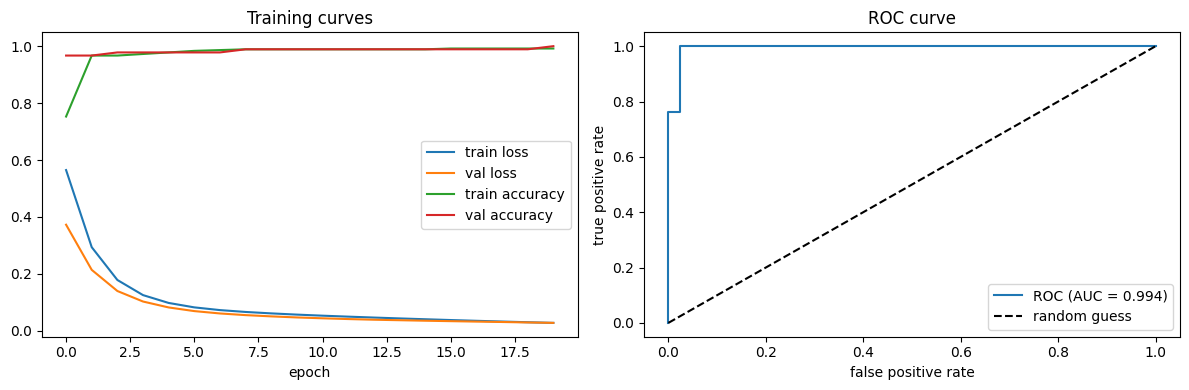

In [ ]:
from sklearn.metrics import roc_curve, auc  # tools for the binary-classification quality plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # two side-by-side plots in one figure

# LEFT — training curves straight from history.history (one value per epoch).
ax1.plot(history.history['loss'], label='train loss')            # what the optimizer minimizes
ax1.plot(history.history['val_loss'], label='val loss')          # generalization gap indicator
ax1.plot(history.history['accuracy'], label='train accuracy')    # fraction right on train
ax1.plot(history.history['val_accuracy'], label='val accuracy')  # fraction right on validation
ax1.set_xlabel('epoch')           # x-axis = training round
ax1.set_title('Training curves')  # title for the students
ax1.legend()                      # small box mapping each line to its label

# RIGHT — ROC curve: true positive rate vs false positive rate at every threshold.
fpr, tpr, _ = roc_curve(y_test, y_prob)  # we discard the thresholds (the '_') — only the curve matters
roc_auc = auc(fpr, tpr)                  # area under the curve; 1.0 = perfect classifier
ax2.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')  # the model's curve
ax2.plot([0, 1], [0, 1], 'k--', label='random guess')   # diagonal = flipping a coin
ax2.set_xlabel('false positive rate')
ax2.set_ylabel('true positive rate')
ax2.set_title('ROC curve')
ax2.legend()

plt.tight_layout()  # stop the two plots from overlapping their labels
plt.show()  # render the figure inline in the notebook

### Things to watch — Practical 1

- **Output and loss must match**: sigmoid output → `binary_crossentropy`. Pairing a sigmoid with `mse` would work numerically but trains worse — the loss no longer means "how wrong is my probability?"
- **Accuracy can hide overfitting**: 97% accuracy with climbing `val_loss` means the model is confidently wrong on new data. Always check the curves, not just the final number.
- **Scale your inputs**: tumour features range from ~0.05 to ~2500. Unscaled, the big-magnitude features dominate and training is slow and unstable.
- **`stratify=y` matters with rare classes**: without it a small test set might contain almost no malignant tumours, and accuracy becomes meaningless.
- **The 0.5 threshold is a choice**: in medicine you might accept more false alarms to catch every cancer — move the threshold down and watch the ROC curve shift.

---
# Practical 2 — Multi-class Classification: Iris

**Task:** given 4 flower measurements (sepal and petal length/width), decide which of **three** species the flower is: *setosa*, *versicolor*, or *virginica*.

Everything from Practical 1 carries over. Two things change, and both changes are forced by the task now having **three** classes instead of two:

1. The output layer becomes `Dense(3, activation='softmax')` — **softmax turns 3 raw scores into 3 probabilities that sum to 1** (one per species).
2. The loss becomes `sparse_categorical_crossentropy` — the categorical (multi-class) version of cross-entropy, in its "sparse" flavour because our labels are plain integers `0/1/2` rather than one-hot vectors.

### The task pipeline

```mermaid
flowchart LR
    A[Dataset<br/>load_iris<br/>150 flowers, 4 features] --> B[Features X and labels y<br/>X: 150 x 4<br/>y: 0=setosa 1=versicolor 2=virginica]
    B --> C[train_test_split<br/>80% train / 20% test<br/>stratify=y keeps 50/50/50 balance]
    C --> D[StandardScaler<br/>fit on TRAIN only]
    D --> E[Model<br/>Dense 64 relu<br/>Dense 64 relu]
    E --> F[Output: Dense 3 softmax<br/>3 probabilities summing to 1<br/>because there are 3 classes]
    F --> G[Loss: sparse_categorical_crossentropy<br/>labels stay as integers 0/1/2]
```

### Step 1 — Load & inspect the data

Same pattern as before: `load_iris()` returns a `Bunch` with `.data` and `.target`. Notice the target is a **class index** (0, 1, 2) — that's what the word *sparse* in the loss name refers to.

In [ ]:
from sklearn.datasets import load_iris  # the most famous tiny dataset in machine learning

iris = load_iris()   # Bunch (dict-like): .data (features), .target (class index), plus names
X = iris.data        # numpy array, shape (150, 4): 150 flowers, 4 measurements each
y = iris.target      # numpy array, shape (150,): class index 0, 1 or 2 (setosa/versicolor/virginica)

print(f"Features shape: {X.shape}")
print(f"Target shape  : {y.shape}")
print(f"Class counts  : {np.bincount(y)}")        # 50 flowers per class — perfectly balanced
print(f"Class names   : {list(iris.target_names)}")  # maps index 0/1/2 to human-readable names

Features shape: (150, 4)
Target shape  : (150,)
Class counts  : [50 50 50]
Class names   : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


### Step 2 — Preprocess: split, then scale

Identical to Practical 1: 80/20 split with `random_state=42` and `stratify=y` (keeps 50/50/50 class balance), then `StandardScaler` fit on training data only.

In [ ]:
from sklearn.model_selection import train_test_split  # same splitter as Practical 1
from sklearn.preprocessing import StandardScaler       # same scaler as Practical 1

# Same recipe as Practical 1 — only the data changed.
# test_size=0.2 (80/20), random_state=42 (reproducible), stratify=y (balanced classes).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()                # fresh scaler — each practical refits its own
X_train = scaler.fit_transform(X_train)  # learn mean/std from train (120 flowers), rescale it
X_test = scaler.transform(X_test)        # apply the SAME mean/std to test (30 flowers)

print(f"Train: X{X_train.shape}, y{y_train.shape}")  # 120 training flowers
print(f"Test : X{X_test.shape}, y{y_test.shape}")    # 30 held-out flowers

Train: X(120, 4), y(120,)
Test : X(30, 4), y(30,)


### Step 3 — Build the model

The two hidden layers are **exactly the same** as Practical 1 — same size, same activation. Only the output layer changes:

- `Dense(3, activation='softmax')` produces **3 numbers, one per species**.
- **Softmax** does two things: exponentiates the raw scores (making them positive) and divides by their sum, so the outputs always add up to 1 and can be read as probabilities: `[0.05, 0.10, 0.85]` means "85% confident it's virginica".
- `model.summary()` shows `(None, 3)` for the output — `None` means "any number of samples"; Keras doesn't fix the batch size.

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(4,)),               # each sample is 4 flower measurements
    layers.Dense(64, activation='relu'),    # hidden layer 1: identical to Practical 1
    layers.Dense(128, activation='relu'),    # hidden layer 2: identical to Practical 1
    layers.Dense(3, activation='softmax'),  # output: 3 probabilities that sum to 1 (one per species)
])

model.summary()  # output column shows (None, 3): None = any batch size, 3 = one probability per class

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,027 (35.26 KB)

 Trainable params: 9,027 (35.26 KB)

 Non-trainable params: 0 (0.00 B)

### Step 4 — Compile

One change from Practical 1: the loss.

- `sparse_categorical_crossentropy` — "categorical" because the task has several classes; "sparse" because the labels are **integers** (`0/1/2`). If we had one-hot vectors like `[0, 0, 1]`, we would drop the `sparse_` and use `categorical_crossentropy`.
- The optimizer (`adam`) and metric (`accuracy`) stay the same — softmax + sparse cross-entropy is the standard multi-class pairing.

In [ ]:
# loss='sparse_categorical_crossentropy': the multi-class cross-entropy for INTEGER labels.
# (If y were one-hot vectors like [0, 0, 1], you would use 'categorical_crossentropy' instead.)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Step 5 — Train with fit()

Same call, same hyper-parameters: `epochs=50`, `batch_size=32`, `validation_split=0.2`. Iris is tiny (120 training flowers), so this finishes in seconds. Again we keep the returned `History` object for plotting.

In [ ]:
# Identical training call to Practical 1 — only the data differs.
history = model.fit(X_train, y_train,          # training features and integer labels
                    validation_split=0.2,      # 20% of train reserved for validation
                    epochs=20,                 # 50 passes over the 120 training flowers
                    batch_size=32,             # weight update after every 32 flowers
                    verbose=1)                 # one progress line per epoch

print("Keys in history.history:", list(history.history.keys()))  # loss, accuracy, val_loss, val_accuracy

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 303ms/step - accuracy: 0.3438 - loss: 1.0948 - val_accuracy: 0.6250 - val_loss: 1.0215
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6875 - loss: 0.9892 - val_accuracy: 0.5833 - val_loss: 0.9371
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7812 - loss: 0.8955 - val_accuracy: 0.6250 - val_loss: 0.8621
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8229 - loss: 0.8112 - val_accuracy: 0.6250 - val_loss: 0.7935
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8333 - loss: 0.7342 - val_accuracy: 0.6250 - val_loss: 0.7315
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8333 - loss: 0.6643 - val_accuracy: 0.6250 - val_loss: 0.6759
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8333 - loss: 0.6018 - val_accuracy: 0.6667 - val_loss: 0.6273
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8438 - loss: 0.5468 - val_accuracy: 0.6667 - val_loss: 0.5852

### Step 6 — Evaluate on the held-out test set

`evaluate()` again returns `[loss, accuracy]` in `compile()` order — the loss is now the sparse categorical cross-entropy.

In [ ]:
# Returns [loss, accuracy] in the same order as compile()'s loss and metrics.
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test loss (sparse_categorical_crossentropy): {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}  ->  {test_accuracy*100:.1f}% of flowers classified correctly")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step - accuracy: 0.7333 - loss: 0.3434
Test loss (sparse_categorical_crossentropy): 0.3434
Test accuracy: 0.7333  ->  73.3% of flowers classified correctly


### Step 7 — Predict: from probabilities to answers

`predict()` returns a **row of 3 probabilities per flower** — shape `(30, 3)`. To get an answer we take `argmax`: the index of the largest probability, which is exactly the class index Keras expects. Comparing predicted indices with `y_test` is all the confusion matrix (next step) does.

In [ ]:
# model.predict returns probability triples, shape (30, 3): one row per test flower.
y_prob = model.predict(X_test, verbose=0)   # e.g. [[0.02, 0.08, 0.90], ...]
y_pred = y_prob.argmax(axis=1)              # argmax along the class axis -> predicted class index (0/1/2)

# Show the first 5 predictions with probabilities, names, and true labels.
for i in range(15):
    probs = np.round(y_prob[i], 2)                                   # round for readable printing
    print(f"sample {i}: probs={probs} -> {iris.target_names[y_pred[i]]}, true {iris.target_names[y_test[i]]}")

sample 0: probs=[0.99 0.01 0.  ] -> setosa, true setosa
sample 1: probs=[0.04 0.2  0.76] -> virginica, true virginica
sample 2: probs=[0.1  0.86 0.04] -> versicolor, true versicolor
sample 3: probs=[0.06 0.91 0.03] -> versicolor, true versicolor
sample 4: probs=[0.99 0.   0.  ] -> setosa, true setosa
sample 5: probs=[0.09 0.25 0.66] -> virginica, true versicolor
sample 6: probs=[1. 0. 0.] -> setosa, true setosa
sample 7: probs=[0.99 0.01 0.  ] -> setosa, true setosa
sample 8: probs=[0.01 0.12 0.87] -> virginica, true virginica
sample 9: probs=[0.13 0.41 0.46] -> virginica, true versicolor
sample 10: probs=[0.  0.1 0.9] -> virginica, true virginica
sample 11: probs=[0.01 0.07 0.93] -> virginica, true virginica
sample 12: probs=[0.01 0.07 0.93] -> virginica, true virginica
sample 13: probs=[0.1  0.29 0.62] -> virginica, true versicolor
sample 14: probs=[0.99 0.   0.  ] -> setosa, true setosa


### Step 8 — Visualize

- **Training curves**: watch `val_loss` dive to near zero — with only 3 well-separated classes the model learns this almost immediately.
- **Confusion matrix**: a table where *rows are true classes* and *columns are predicted classes*. Numbers on the diagonal are correct predictions; anything off-diagonal is a specific kind of mistake. For Iris we expect (almost) a perfect diagonal.

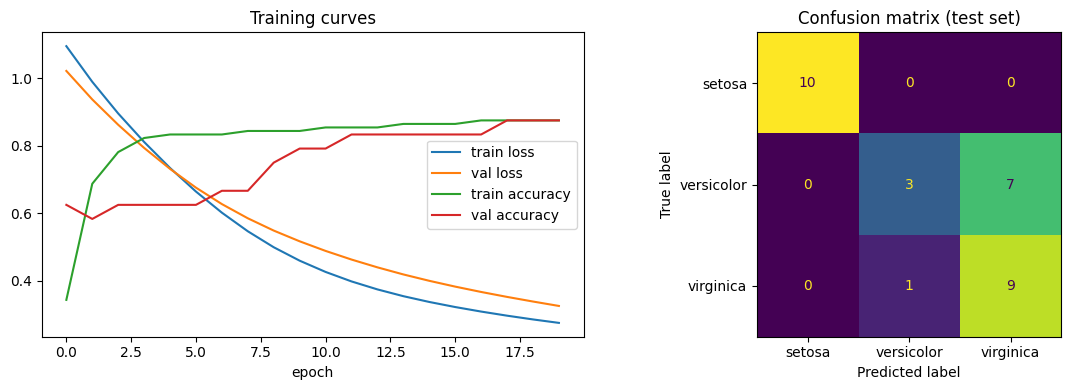

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # standard multi-class quality plot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # side-by-side plots again

# LEFT — training curves from the History object.
ax1.plot(history.history['loss'], label='train loss')
ax1.plot(history.history['val_loss'], label='val loss')
ax1.plot(history.history['accuracy'], label='train accuracy')
ax1.plot(history.history['val_accuracy'], label='val accuracy')
ax1.set_xlabel('epoch')
ax1.set_title('Training curves')
ax1.legend()

# RIGHT — confusion matrix: rows = true class, columns = predicted class.
cm = confusion_matrix(y_test, y_pred)  # a 3x3 integer table of counts
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(ax=ax2, colorbar=False)  # renders the table
ax2.set_title('Confusion matrix (test set)')

plt.tight_layout()
plt.show()  # render both plots inline

### Things to watch — Practical 2

- **The number of output units = the number of classes.** Three species → `Dense(3)`. If you forget and write `Dense(1)`, training will still "run" and produce garbage — Keras can't know your intent.
- **softmax + `sparse_categorical_crossentropy` is the pair** — just like sigmoid + `binary_crossentropy` was in Practical 1. The loss compares the probability the model gave the *correct* class against 1.0.
- **Sparse vs one-hot**: `sparse_categorical_crossentropy` wants integer labels (`0/1/2`); `categorical_crossentropy` wants one-hot vectors (`[0,0,1]`). Mixing them up is the most common beginner error — the error message is confusing, so remember: *look at your label format first*.
- **argmax, not threshold**: binary used `> 0.5`; multi-class uses "pick the biggest". Same idea — turn model outputs into a decision.
- **Iris is unusually easy** — don't expect near-100% accuracy on messier real-world multi-class problems.

---
# Practical 3 — Regression: California Housing

**Task:** predict the **median house value** of a California district (in units of $100,000) from 8 features such as median income, house age, and average rooms.

This is *regression*: the answer is a **number**, not a category. Two things change, and again the task dictates both:

1. The output layer becomes `Dense(1)` with **no activation** — a *linear* output that can produce any real number, because prices aren't confined to 0–1.
2. The loss becomes `'mse'` (mean squared error), with `'mae'` (mean absolute error) as the human-readable metric. **No `stratify`** this time — that argument is only for classification labels.

### The task pipeline

```mermaid
flowchart LR
    A[Dataset<br/>fetch_california_housing<br/>20640 districts, 8 features] --> B[Features X and target y<br/>X: 20640 x 8<br/>y: price in $100k, ~0.15 to 5.0]
    B --> C[train_test_split<br/>80% train / 20% test<br/>no stratify — regression has no classes]
    C --> D[StandardScaler<br/>fit on TRAIN only<br/>essential for regression!]
    D --> E[Model<br/>Dense 64 relu<br/>Dense 64 relu]
    E --> F[Output: Dense 1, NO activation<br/>any real number = a price<br/>because the answer is numeric]
    F --> G[Loss: mse<br/>metric: mae<br/>plus R2 for reporting]
```

### Step 1 — Load & inspect the data

`fetch_california_housing()` downloads ~20,000 districts. This time the target is a **continuous value** — check its range, because regression losses live on the scale of the targets (a loss of 0.3 means something very different when targets span 0–5 vs 0–5,000,000).

In [ ]:
from sklearn.datasets import fetch_california_housing  # larger, real-world regression dataset

housing = fetch_california_housing()  # Bunch with .data (features) and .target (prices)
X = housing.data    # numpy array, shape (20640, 8): 20,640 districts, 8 numeric features
y = housing.target  # numpy array, shape (20640,): median house value in units of $100,000

print(f"Features shape: {X.shape}")
print(f"Target range  : min={y.min():.2f}, max={y.max():.2f} (units of $100,000)")  # approx 0.15 to 5.0
print(f"Feature names : {list(housing.feature_names)}")  # MedInc, HouseAge, AveRooms, ...
print(f"Example       : a target of {y[0]:.2f} means ${y[0]*100_000:,.0f}")  # the '_'_separator is just readability

Features shape: (20640, 8)
Target range  : min=0.15, max=5.00 (units of $100,000)
Feature names : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Example       : a target of 4.53 means $452,600


### Step 2 — Preprocess: split, then scale

Same 80/20 split with `random_state=42` — but **no `stratify`**: that parameter needs class labels, and house prices aren't classes. Scaling is even more important here than for the classifiers: features like `MedInc` (~0.5–15) and `AveOccup` (~1–1000) have wildly different scales, and unscaled regression often trains slowly or diverges.

In [ ]:
from sklearn.model_selection import train_test_split  # same splitter as before
from sklearn.preprocessing import StandardScaler       # same scaler as before

# NOTE: no stratify= here — stratification only makes sense for classification labels.
# test_size=0.2 and random_state=42 stay, so the split is still reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()                # fresh scaler for this dataset
X_train = scaler.fit_transform(X_train)  # learn feature means/stds from the 16,512 training districts
X_test = scaler.transform(X_test)        # apply the same transform to the 4,128 test districts

print(f"Train: X{X_train.shape}, y{y_train.shape}")  # 16,512 training districts
print(f"Test : X{X_test.shape}, y{y_test.shape}")    # 4,128 held-out districts

Train: X(16512, 8), y(16512,)
Test : X(4128, 8), y(4128,)


### Step 3 — Build the model

Hidden layers: identical again. The output is the interesting part:

- `layers.Dense(1)` with **no `activation` argument** — that means the *linear* (identity) activation. The layer just outputs `w · x + b`, which can be any real number. Perfect for prices.
- Compare the three outputs you've now seen: **sigmoid** (1 unit, 0–1, binary), **softmax** (3 units, probabilities, multi-class), **linear** (1 unit, any number, regression). Choosing among these three is the first decision in every new project.

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(8,)),             # each sample is 8 district statistics
    layers.Dense(64, activation='relu'),  # hidden layer 1: identical to both classifiers
    layers.Dense(64, activation='relu'),  # hidden layer 2: identical to both classifiers
    layers.Dense(1),                      # output: 1 LINEAR unit (no activation) -> any real number = a price
])

model.summary()  # the output shape (None, 1) is one predicted price per district

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

### Step 4 — Compile

- **loss='mse'** (mean squared error): the average of `(predicted − actual)²`. Squaring punishes large mistakes heavily — a $200k miss costs far more than two $100k misses.
- **metrics=['mae']** (mean absolute error): the average `|predicted − actual|`, which is much easier to explain: "on average we're off by about $X".
- `optimizer='adam'` — same as always.

In [ ]:
# loss='mse'      : mean squared error — the standard regression loss (punishes big misses quadratically).
# metrics=['mae']: mean ABSOLUTE error — reported for humans as "average dollar error".
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

### Step 5 — Train with fit()

Same training call one last time. With ~16k training samples this takes a bit longer than Iris but still under a minute on Colab. Keep the `History` — we plot `loss` vs `val_loss` in step 8.

In [ ]:
# Identical hyper-parameters to the classifiers: the workflow really is the same.
history = model.fit(X_train, y_train,          # training features and continuous targets
                    validation_split=0.2,      # 20% of train reserved for validation
                    epochs=20,                 # 50 passes over ~16.5k districts
                    batch_size=32,             # weight update after every 32 districts
                    verbose=1)                 # one progress line per epoch

print("Keys in history.history:", list(history.history.keys()))  # loss, mae, val_loss, val_mae

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2936 - mae: 0.3766 - val_loss: 0.3144 - val_mae: 0.3922
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2905 - mae: 0.3740 - val_loss: 0.3131 - val_mae: 0.3917
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2881 - mae: 0.3718 - val_loss: 0.3106 - val_mae: 0.3900
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2863 - mae: 0.3704 - val_loss: 0.3088 - val_mae: 0.3889
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2817 - mae: 0.3677 - val_loss: 0.3069 - val_mae: 0.3870
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2808 - mae: 0.3664 - val_loss: 0.3050 - val_mae: 0.3851
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2783 - mae: 0.3644 - val_loss: 0.3038 - val_mae: 0.3841
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2760 - mae: 0.3625 - val_loss: 0.3038 - val_mae: 0.3839
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

### Step 6 — Evaluate on the held-out test set

`evaluate()` returns `[loss, mae]` in `compile()` order. MSE is in *squared* $100k units (hard to read), so we also report MAE as dollars — the number you'd quote to a friend.

In [ ]:
# Returns [loss, mae] in compile() order; verbose=0 silences the progress bar.
test_mse, test_mae = model.evaluate(X_test, y_test, verbose=1)

print(f"Test MSE: {test_mse:.4f}  (squared $100k units — small is good, but hard to read)")
print(f"Test MAE: {test_mae:.4f}  ->  on average the model is off by about ${test_mae*100_000:,.0f} per house")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2910 - mae: 0.3735
Test MSE: 0.2910  (squared $100k units — small is good, but hard to read)
Test MAE: 0.3735  ->  on average the model is off by about $37,349 per house


### Step 7 — Predict and compute R²

`predict()` returns plain numbers now — no sigmoid to invert, no argmax needed; the output *is* the answer.

We also report **R²** (coefficient of determination): 1.0 = perfect predictions, 0.0 = no better than always guessing the average price, negative = worse than that. It's the standard summary number for regression.

In [ ]:
from sklearn.metrics import r2_score  # standard "how good is my regression" summary number

# model.predict returns price estimates, shape (4128, 1); .ravel() flattens to (4128,).
y_pred = model.predict(X_test, verbose=0).ravel()

r2 = r2_score(y_test, y_pred)  # 1.0 = perfect, 0.0 = as good as guessing the mean, <0 = worse than mean
print(f"R² on test set: {r2:.3f}  (target for this dataset with a small model: > 0.7)")

# Show 5 sample predictions next to the true prices.
for i in range(5):
    print(f"sample {i}: predicted ${y_pred[i]*100_000:,.0f}, actual ${y_test[i]*100_000:,.0f}")

R² on test set: 0.778  (target for this dataset with a small model: > 0.7)
sample 0: predicted $37,276, actual $47,700
sample 1: predicted $109,309, actual $45,800
sample 2: predicted $497,979, actual $500,001
sample 3: predicted $244,031, actual $218,600
sample 4: predicted $291,291, actual $278,000


### Step 8 — Visualize

- **Training curves**: regression loss starts large and decays smoothly — that "ski slope" is what healthy regression training looks like.
- **Predicted-vs-actual scatter**: one dot per district. Dots on the red dashed line are perfect predictions; the cloud's spread around the line is the model's error. Note the ceiling: many houses were capped at $500k in the data, which is why a horizontal band of dots sits at 5.0.

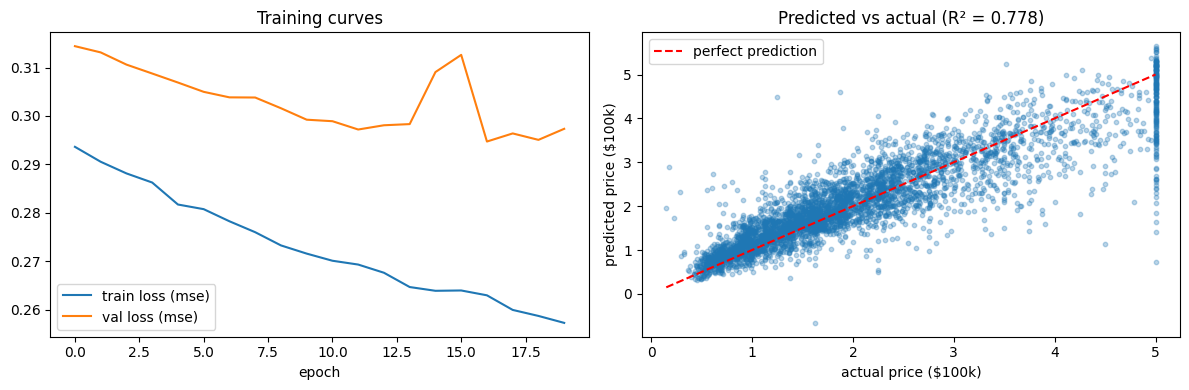

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # side-by-side plots one last time

# LEFT — training curves: watch val_loss track train loss (a small gap = healthy).
ax1.plot(history.history['loss'], label='train loss (mse)')
ax1.plot(history.history['val_loss'], label='val loss (mse)')
ax1.set_xlabel('epoch')
ax1.set_title('Training curves')
ax1.legend()

# RIGHT — predicted vs actual: dots on the diagonal mean perfect predictions.
ax2.scatter(y_test, y_pred, alpha=0.3, s=10)  # one semi-transparent dot per district (4,128 total)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],  # diagonal from min to max
         'r--', label='perfect prediction')  # red dashed line
ax2.set_xlabel('actual price ($100k)')
ax2.set_ylabel('predicted price ($100k)')
ax2.set_title(f'Predicted vs actual (R² = {r2:.3f})')
ax2.legend()

plt.tight_layout()
plt.show()  # render inline

---
## Recap — five Keras calls built all three models

You just trained a binary classifier, a multi-class classifier, and a regressor. Different tasks, different outputs and losses — but the **same five calls** did the work every time:

| # | Call | What it does | Used in |
|---|---|---|---|
| 1 | `keras.Sequential([...])` | Stacks layers into a network: 2 × `Dense(64, 'relu')` + one task-specific output layer | P1, P2, P3 |
| 2 | `model.compile(...)` | Chooses the optimizer (`adam`), the loss (`binary_crossentropy` / `sparse_categorical_crossentropy` / `mse`), and human-readable metrics | P1, P2, P3 |
| 3 | `model.fit(...)` | Trains for `epochs=50` in `batch_size=32` chunks, holds out `validation_split=0.2`, and returns a `History` of curves | P1, P2, P3 |
| 4 | `model.evaluate(...)` | Measures loss + metrics on the held-out test set — the honest final score | P1, P2, P3 |
| 5 | `model.predict(...)` | Produces raw outputs (probabilities or prices) for new data; you threshold (`> 0.5`), `argmax`, or use the value directly | P1, P2, P3 |

**The one thing that changed per task was the ending:**

| Task | Output layer | Loss | Answer extraction |
|---|---|---|---|
| Binary classification | `Dense(1, 'sigmoid')` | `binary_crossentropy` | `prob > 0.5` |
| Multi-class classification | `Dense(3, 'softmax')` | `sparse_categorical_crossentropy` | `argmax(probabilities)` |
| Regression | `Dense(1)` (linear) | `mse` | the value itself |

Next up: the PyTorch notebook (`02_pytorch_practicals.ipynb`) solves these **same three tasks** with the explicit training loop — keep this notebook open side-by-side and match the steps using the vocabulary table from Section 0.